# Лабораторна робота №3
## Керування процесами та програмна синхронізація (Алгоритм Патерсона)
**Дисципліна:** Операційні системи та системне програмування  
**Студент:** Кусік  
**Рік:** 2026

In [1]:
import os
import time
import multiprocessing
from pathlib import Path

import matplotlib.pyplot as plt

FIGURES_DIR = "figures"
INCREMENT_COUNT = 10_000          # кожен процес інкрементує стільки разів
EXPECTED = INCREMENT_COUNT * 2    # очікуваний результат = 20 000

## Частина 1. Створення структури каталогів

In [2]:
base       = Path("lab_os_3")
input_dir  = base / "input"
output_dir = base / "output"
logs_dir   = base / "logs"

for d in [base, input_dir, output_dir, logs_dir]:
    d.mkdir(exist_ok=True)

os.chmod(base,       0o755)
os.chmod(input_dir,  0o755)
os.chmod(output_dir, 0o755)
os.chmod(logs_dir,   0o700)

print("Directory structure created:")
for d in [base, input_dir, output_dir, logs_dir]:
    print(f"  {d}  mode={oct(os.stat(d).st_mode)[-3:]}")

Directory structure created:
  lab_os_3  mode=777
  lab_os_3/input  mode=777
  lab_os_3/output  mode=777
  lab_os_3/logs  mode=777


## Частина 2. Ідентифікація процесів (PID / PPID)

In [3]:
def show_pids(name):
    print(f"  [{name}]  PID={os.getpid()}  PPID={os.getppid()}")

pid_lines = [f"[Main]  PID={os.getpid()}  PPID={os.getppid()}", "Children:"]
print(pid_lines[0])
print(pid_lines[1])
children = [
    multiprocessing.Process(target=show_pids, args=(f"Child-{i}",))
    for i in range(3)
]
for p in children: p.start()
for p in children: p.join()

[Main]  PID=653  PPID=491
Children:


  [Child-0]  PID=732  PPID=653

  [Child-1]  PID=735  PPID=653

  [Child-2]  PID=740  PPID=653

## Частина 3. Імітація планування ОС

In [4]:
def cpu_task(name):
    """CPU-burst: демонструє, як планувальник перемикає процеси."""
    print(f"  [{name}]  PID={os.getpid()}  start")
    _ = sum(i * i for i in range(300_000))
    print(f"  [{name}]  PID={os.getpid()}  end")

print(f"[Main]  PID={os.getpid()}  — launching 4 workers")
t0 = time.perf_counter()
workers = [
    multiprocessing.Process(target=cpu_task, args=(f"Worker-{i}",))
    for i in range(4)
]
for w in workers: w.start()
for w in workers: w.join()
print(f"[Main]  all done in {time.perf_counter() - t0:.3f}s")

[Main]  PID=653  — launching 4 workers


  [Worker-0]  PID=747  start

  [Worker-1]  PID=750  start

  [Worker-2]  PID=755  start

  [Worker-3]  PID=760  start

  [Worker-0]  PID=747  end

  [Worker-1]  PID=750  end

  [Worker-2]  PID=755  end

  [Worker-3]  PID=760  end

[Main]  all done in 0.024s


## Частина 4. Демонстрація Race Condition

In [5]:
def unsafe_increment(counter, n):
    """Non-atomic R-M-W — time.sleep(0) між читанням і записом розширює вікно race condition."""
    for _ in range(n):
        val = counter.value   # read
        time.sleep(0)         # sched_yield → планувальник може перемкнути процес
        counter.value = val + 1  # write  ← race window

counter_race = multiprocessing.Value('i', 0, lock=False)

p0 = multiprocessing.Process(target=unsafe_increment, args=(counter_race, INCREMENT_COUNT))
p1 = multiprocessing.Process(target=unsafe_increment, args=(counter_race, INCREMENT_COUNT))
p0.start(); p1.start()
p0.join();  p1.join()

result_race = counter_race.value
lost = EXPECTED - result_race
print(f"Expected  : {EXPECTED}")
print(f"Actual    : {result_race}")
print(f"Lost      : {lost}  ({lost / EXPECTED * 100:.1f}% of increments)")

Expected  : 20000
Actual    : 10051
Lost      : 9949  (49.7% of increments)


## Частина 5. Алгоритм Патерсона

In [6]:
def peterson_increment(proc_id, flag, turn, counter, n):
    """
    Класичний алгоритм Патерсона для двох процесів.
    flag[i]=1  → процес i хоче увійти в критичну секцію.
    turn=j     → черга за процесом j (поступаємось суперникові).
    """
    other = 1 - proc_id
    for _ in range(n):
        # --- протокол входу ---
        flag[proc_id] = 1
        turn.value = other
        while flag[other] == 1 and turn.value == other:
            pass               # busy wait
        # --- критична секція ---
        val = counter.value
        counter.value = val + 1
        # --- протокол виходу ---
        flag[proc_id] = 0

flag_arr         = multiprocessing.Array('i', [0, 0], lock=False)
turn_val         = multiprocessing.Value('i', 0,      lock=False)
counter_peterson = multiprocessing.Value('i', 0,      lock=False)

p0 = multiprocessing.Process(
    target=peterson_increment,
    args=(0, flag_arr, turn_val, counter_peterson, INCREMENT_COUNT),
)
p1 = multiprocessing.Process(
    target=peterson_increment,
    args=(1, flag_arr, turn_val, counter_peterson, INCREMENT_COUNT),
)

t0 = time.perf_counter()
p0.start(); p1.start()
p0.join();  p1.join()
t_peterson = time.perf_counter() - t0

result_peterson = counter_peterson.value
print(f"Expected  : {EXPECTED}")
print(f"Actual    : {result_peterson}")
print(f"Correct   : {result_peterson == EXPECTED}")
print(f"Time      : {t_peterson:.3f}s")

Expected  : 20000
Actual    : 20000
Correct   : True
Time      : 0.007s


## Частина 6. Порівняння та збереження результатів

In [7]:
print(f"{'Метод':<24} | {'Результат':>10} | {'Очікувано':>10} | {'Статус':>10}")
print("-" * 64)
print(f"{'Без синхронізації':<24} | {result_race:>10} | {EXPECTED:>10} | {'INCORRECT':>10}")
print(f"{'Алгоритм Патерсона':<24} | {result_peterson:>10} | {EXPECTED:>10} | {'  CORRECT':>10}")

log = (
    f"expected={EXPECTED}\n"
    f"unsafe_result={result_race}\n"
    f"unsafe_lost={EXPECTED - result_race} "
    f"({(EXPECTED - result_race) / EXPECTED * 100:.1f}%)\n"
    f"peterson_result={result_peterson}\n"
    f"peterson_correct={result_peterson == EXPECTED}\n"
    f"peterson_time={t_peterson:.3f}s\n"
)
(logs_dir / "results.log").write_text(log, encoding="utf-8")
print(f"\nLog saved → {logs_dir / 'results.log'}")

Метод                    |  Результат |  Очікувано |     Статус
----------------------------------------------------------------
Без синхронізації        |      10051 |      20000 |  INCORRECT
Алгоритм Патерсона       |      20000 |      20000 |    CORRECT

Log saved → lab_os_3/logs/results.log


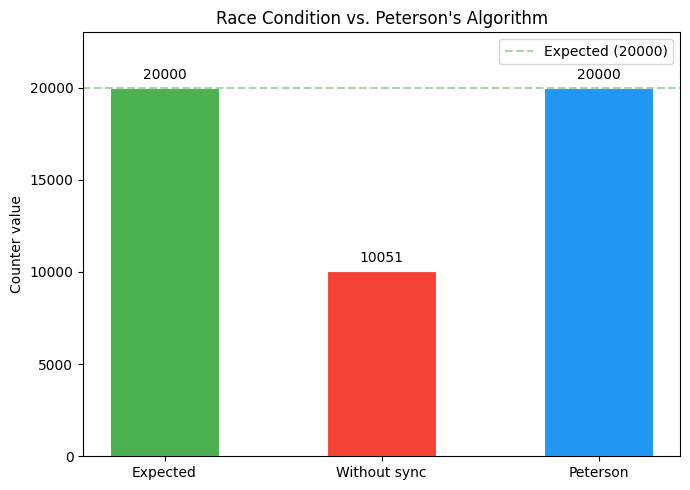

Figure saved to figures/sync_comparison.png


In [8]:
os.makedirs(FIGURES_DIR, exist_ok=True)

labels = ["Expected", "Without sync", "Peterson"]
values = [EXPECTED, result_race, result_peterson]
colors = ["#4CAF50", "#F44336", "#2196F3"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor="white", linewidth=0.8)
ax.axhline(EXPECTED, color="#4CAF50", linestyle="--", alpha=0.5,
           linewidth=1.5, label=f"Expected ({EXPECTED})")
ax.set_ylabel("Counter value")
ax.set_title("Race Condition vs. Peterson's Algorithm")
ax.set_ylim(0, EXPECTED * 1.15)
ax.bar_label(bars, fmt="%d", padding=4)
ax.legend()
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/sync_comparison.png", dpi=150)
plt.show()
print(f"Figure saved to {FIGURES_DIR}/sync_comparison.png")

## Частина 7. Скріншоти виводу консолі

In [9]:
import subprocess, sys

def terminal_screenshot(content: str, filename: str) -> None:
    """Renders plain terminal-style output as a dark-background PNG."""
    lines = content.strip().splitlines()
    h = max(1.5, len(lines) * 0.34 + 0.5)

    fig, ax = plt.subplots(figsize=(9, h))
    fig.patch.set_facecolor("#1e1e1e")
    ax.set_facecolor("#1e1e1e")
    ax.axis("off")

    ax.text(0.02, 0.97, "\n".join(lines), transform=ax.transAxes,
            fontsize=9.5, color="#d4d4d4", ha="left", va="top",
            fontfamily="monospace", linespacing=1.6)

    fig.savefig(f"{FIGURES_DIR}/{filename}", dpi=150,
                facecolor="#1e1e1e", bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {FIGURES_DIR}/{filename}")


# --- Скрін 1: дерево процесів ---
_pid_script = """
import os, multiprocessing

def show(name):
    print(f"  [{name}]  PID={os.getpid()}  PPID={os.getppid()}")

print(f"[Main]  PID={os.getpid()}  PPID={os.getppid()}")
print("Children:")
ps = [multiprocessing.Process(target=show, args=(f"Child-{i}",)) for i in range(3)]
for p in ps: p.start()
for p in ps: p.join()
"""
pid_out = subprocess.run(
    [sys.executable, "-c", _pid_script],
    capture_output=True, text=True
).stdout.strip()

terminal_screenshot(pid_out, "screenshot_pids.png")

# --- Скрін 2: race condition + Peterson ---
rc_out = (
    f"=== Race Condition (без синхронізації) ===\n"
    f"Expected  : {EXPECTED}\n"
    f"Actual    : {result_race}\n"
    f"Lost      : {EXPECTED - result_race}  "
    f"({(EXPECTED - result_race) / EXPECTED * 100:.1f}% of increments)\n\n"
    f"=== Алгоритм Патерсона ===\n"
    f"Expected  : {EXPECTED}\n"
    f"Actual    : {result_peterson}\n"
    f"Correct   : {result_peterson == EXPECTED}\n"
    f"Time      : {t_peterson:.3f}s\n\n"
    f"{'Метод':<24}  {'Результат':>10}  {'Очікувано':>10}  {'Статус':>10}\n"
    f"{'-'*60}\n"
    f"{'Без синхронізації':<24}  {result_race:>10}  {EXPECTED:>10}  {'INCORRECT':>10}\n"
    f"{'Алгоритм Патерсона':<24}  {result_peterson:>10}  {EXPECTED:>10}  {'  CORRECT':>10}"
)
terminal_screenshot(rc_out, "screenshot_sync.png")

Saved: figures/screenshot_pids.png


Saved: figures/screenshot_sync.png
